<a href="https://www.kaggle.com/code/gherbi019/binary-classification-of-breast-cancer-using-cnn?scriptVersionId=261125587" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import time
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

2025-09-10 20:24:26.690546: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757535866.876810      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757535866.943683      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# Chemins pour dataset
data_dir = '/kaggle/input/multicancer-dataset/Cancer_Dataset'
train_dir = os.path.join(data_dir, 'train')
valid_dir = os.path.join(data_dir, 'val')

# Paramètres
img_height, img_width = 224 , 224
batch_size = 32   
epochs = 50       

In [3]:
# Générateurs d'images  pour l'entraînement
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest'
)

# Générateur d'images pour la validation
validation_datagen = ImageDataGenerator(rescale=1./255)

In [4]:
# Chargement des données d'entraînement
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  
    classes=['breast_benign', 'breast_malignant'], 
    shuffle=True,
    seed=42
)

# Chargement des données de validation
validation_generator = validation_datagen.flow_from_directory(
    valid_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  
    classes=['breast_benign', 'breast_malignant'], 
    shuffle=True,
    seed=42
)

Found 8000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


In [5]:
# Création du modèle CNN
def create_cnn_model():
    model = Sequential([
        # Première couche
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(img_height, img_width, 3)),
        MaxPooling2D(pool_size=(2, 2)),
        
        # Deuxième couche
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        
        # Troisième couche de convolution
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        
        # Quatrième couche de convolution
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        
        # Aplatissement
        Flatten(),
        
        # Couches entièrement connectées
        Dense(512, activation='relu'),
        Dropout(0.5),  
        Dense(1, activation='sigmoid') 
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy','precision','recall']
    )
    
    return model

In [6]:
# Créer le modèle
model = create_cnn_model()

# Résumé du modèle
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1757535884.883948      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      25,690,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 26,079,553 (99.49 MB)

 Trainable params: 26,079,553 (99.49 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Callbacks
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [8]:
# Entraînement du modèle
start_training = time.time()
history = model.fit(
    train_generator,
    steps_per_epoch=int(np.ceil(train_generator.samples / batch_size)),
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=int(np.ceil(validation_generator.samples / batch_size)),
    callbacks=[checkpoint, early_stopping]
)
end_training = time.time()
training_time = end_training - start_training
print(f"\n⏱️  TEMPS TOTAL D'ENTRAÎNEMENT: {training_time:.2f} secondes")

# Charger le meilleur modèle
model.load_weights('best_model.h5')

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1757535891.805952      74 service.cc:148] XLA service 0x7b46a8011dd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757535891.806858      74 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1757535892.259252      74 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/250 ━━━━━━━━━━━━━━━━━━━━ 38:10 9s/step - accuracy: 0.5312 - loss: 0.6999 - precision: 0.5000 - recall: 0.2667

I0000 00:00:1757535896.812380      74 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.7389 - loss: 0.5088 - precision: 0.7363 - recall: 0.7483
Epoch 1: val_accuracy improved from -inf to 0.82700, saving model to best_model.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 177s 672ms/step - accuracy: 0.7392 - loss: 0.5085 - precision: 0.7365 - recall: 0.7487 - val_accuracy: 0.8270 - val_loss: 0.4810 - val_precision: 0.9383 - val_recall: 0.7000
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.8754 - loss: 0.3152 - precision: 0.8581 - recall: 0.8966
Epoch 2: val_accuracy improved from 0.82700 to 0.87900, saving model to best_model.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 132s 527ms/step - accuracy: 0.8754 - loss: 0.3152 - precision: 0.8581 - recall: 0.8966 - val_accuracy: 0.8790 - val_loss: 0.3382 - val_precision: 0.9317 - val_recall: 0.8180
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.8816 - loss: 0.2937 - precision: 0.8765 - recall: 0.8906
Epoch 3: val_accuracy improved from 0.87900 to 0.89050, savin

In [9]:
#  visualiser les performances
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))
    plt.figure(figsize=(12, 5))
    
    # Tracer la précisionclass_names=['breast_benign', 'breast_malignant']
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Précision entraînement')
    plt.plot(epochs_range, val_acc, label='Précision validation')
    plt.title('Précision entraînement et validation')
    plt.legend()
    
    # Tracer la perte
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Perte entraînement')
    plt.plot(epochs_range, val_loss, label='Perte validation')
    plt.title('Perte entraînement et validation')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('performance.png')
    plt.show()

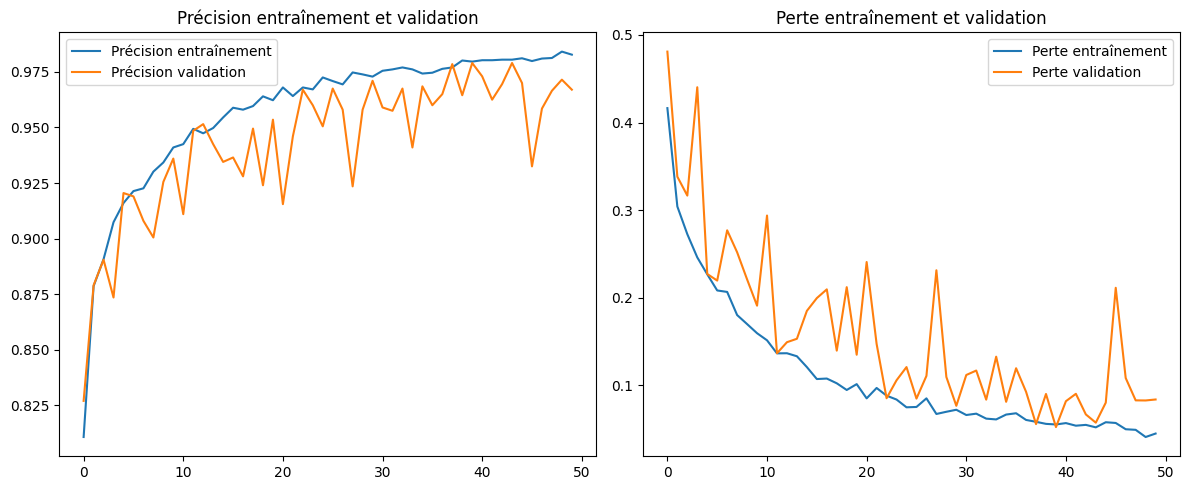

63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 180ms/step - accuracy: 0.9763 - loss: 0.0566 - precision: 0.9911 - recall: 0.9607
Perte: 0.0524
Précision: 0.9790
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 182ms/step


In [10]:
# Visualiser l'historique d'entraînement
plot_training_history(history)

# Évaluation du modèle
evaluation = model.evaluate(validation_generator)
print(f"Perte: {evaluation[0]:.4f}")
print(f"Précision: {evaluation[1]:.4f}")

# Prédictions sur l'ensemble de validation
validation_generator.reset()  
predictions = model.predict(validation_generator, steps=int(np.ceil(validation_generator.samples/batch_size)))
predicted_classes = (predictions > 0.5).astype(int)

# Récupérer les vraies classes
true_classes = validation_generator.classes

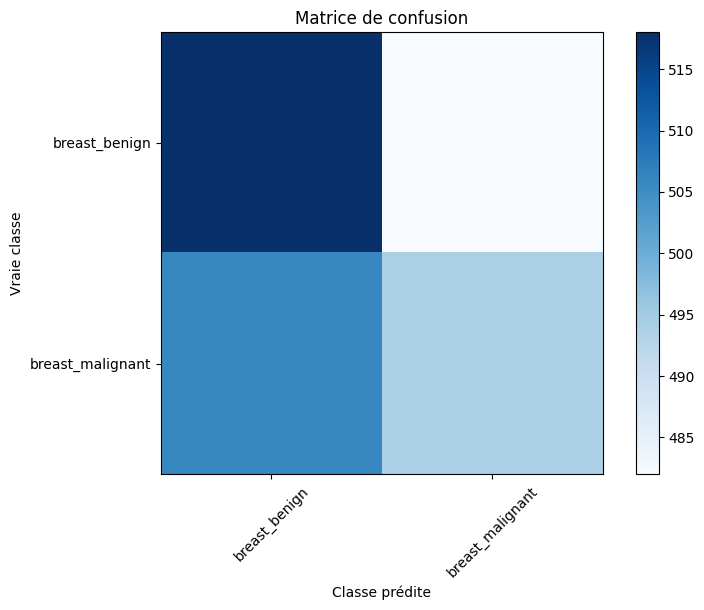

                  precision    recall  f1-score   support

   breast_benign       0.51      0.52      0.51      1000
breast_malignant       0.51      0.49      0.50      1000

        accuracy                           0.51      2000
       macro avg       0.51      0.51      0.51      2000
    weighted avg       0.51      0.51      0.51      2000



In [11]:
# Matrice de confusion
cm = confusion_matrix(true_classes, predicted_classes)
class_names = list(train_generator.class_indices.keys())


# Afficher la matrice de confusion
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matrice de confusion')
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.tight_layout()
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.savefig('confusion_matrix.png')
plt.show()

# Rapport de classification
print(classification_report(true_classes, predicted_classes, target_names=class_names))

In [12]:
# Fonction pour la prédiction d'une image unique
def predict_image(image_path, model):
    from tensorflow.keras.preprocessing import image
    
    # Charger l'image et la redimensionner
    img = image.load_img(image_path, target_size=(img_height, img_width))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Créer un batch
    img_array = img_array / 255.0  # Normaliser
    
    # Faire la prédiction
    prediction = model.predict(img_array)
    
    # Convertir en classe (0 pour bénigne, 1 pour maligne)
    prediction_class = int(prediction[0][0] > 0.5)
    
    # Renvoyer le nom de la classe
    class_name = list(train_generator.class_indices.keys())[prediction_class]
    confidence = prediction[0][0] if prediction_class == 1 else 1 - prediction[0][0]
    
    return class_name, confidence

# Exemple d'utilisation
# image_path = "votre image"
# class_name, confidence = predict_image(image_path, model)
# print(f"Classe prédite: {class_name} avec une confiance de {confidence:.2f}")

# Sauvegarde du modèle complet
model.save('cancer_classification_model.h5')
print("Modèle sauvegardé sous 'cancer_classification_model.h5'")

Modèle sauvegardé sous 'cancer_classification_model.h5'
